In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import decorate, configure_plot_style, AIBM_COLORS

configure_plot_style()

# Life Expectancy

## WEF data

Now let's see how these results compare to WEF.
Here's the data pulled from the PDF report.

In [3]:
from utils import read_wef_file

wef = read_wef_file("wef_life_expectancy.csv").drop(columns=['diff', 'left', 'right'])
wef.shape

(146, 4)

In [4]:
wef.head()

,country,page_number,score,rank
code,,,,
ALB,Albania,83,1.033,79
DZA,Algeria,85,0.990,144
AGO,Angola,87,1.050,55
ARG,Argentina,89,1.051,51
ARM,Armenia,91,1.060,1


In [5]:
wef.tail()

,country,page_number,score,rank
code,,,,
UZB,Uzbekistan,365,1.036,76
VUT,Vanuatu,367,1.054,45
VNM,Vietnam,369,1.060,1
ZMB,Zambia,371,1.060,1
ZWE,Zimbabwe,373,1.060,1


In [6]:
wef['rank'].value_counts(dropna=False).head()

rank
1     37
79     1
93     1
63     1
67     1
Name: count, dtype: int64

In [7]:
dinged = wef['score'] < 1.06
dinged.sum()

108

Here's the distribution of WEF scores.

In [8]:
wef.sort_values(by='score').head()

,country,page_number,score,rank
code,,,,
QAT,Qatar,303,0.955,146
JOR,Jordan,221,0.987,145
DZA,Algeria,85,0.990,144
BHR,Bahrain,99,0.993,143
MLI,Mali,251,0.993,142


In [9]:
wef.sort_values(by='score').tail(37)

,country,page_number,score,rank
code,,,,
ARM,Armenia,91,1.06,1
UGA,Uganda,351,1.06,1
BLR,Belarus,105,1.06,1
VNM,Vietnam,369,1.06,1
BRA,Brazil,121,1.06,1
LKA,Sri Lanka,329,1.06,1
BWA,Botswana,119,1.06,1
THA,Thailand,341,1.06,1
BLZ,Belize,109,1.06,1


## WHO HALE data

Downloaded using the GHO OData API (who_data.py)

https://www.who.int/data/gho/info/gho-odata-api

In [10]:
filename = 'who_hale_data.csv'

who_all = pd.read_csv(filename)
who_all.head()

,Country,CountryCode,Year,Sex,HALE_Years,HALE_Low,HALE_High,Comments,DataSource
0,AFG,COUNTRY,2000,SEX_BTSX,46.027950,44.939602,47.308578,NaN,NaN
1,AFG,COUNTRY,2001,SEX_BTSX,46.116121,44.907570,47.033098,NaN,NaN
2,AFG,COUNTRY,2002,SEX_BTSX,47.184852,46.147952,48.308520,NaN,NaN
3,AFG,COUNTRY,2003,SEX_BTSX,47.977953,47.016452,48.976006,NaN,NaN
4,AFG,COUNTRY,2004,SEX_BTSX,48.324761,47.311935,49.325042,NaN,NaN


In [11]:
who_all = who_all.query('Year <= 2019')

In [12]:
grouped = who_all.groupby(["Sex", "Country"]).last()
grouped

CountryCode  Year  HALE_Years   HALE_Low  HALE_High  \
Sex      Country                                                       
SEX_BTSX AFG         COUNTRY  2019   52.309370  51.423437  53.176338   
         AFR          REGION  2019   55.813171  54.947024  56.724093   
         AGO         COUNTRY  2019   54.316650  53.294030  55.470551   
         ALB         COUNTRY  2019   68.405255  67.685856  69.158815   
         AMR          REGION  2019   65.757890  65.028885  66.584067   
...                      ...   ...         ...        ...        ...   
SEX_MLE  WSM         COUNTRY  2019   61.106369  60.345858  61.872533   
         YEM         COUNTRY  2019   56.396105  55.596425  57.531084   
         ZAF         COUNTRY  2019   54.654250  54.035322  55.301890   
         ZMB         COUNTRY  2019   52.668565  51.819538  53.784751   
         ZWE         COUNTRY  2019   50.899161  50.198941  51.765758   

                  Comments  DataSource  
Sex      Country                        
SEX_BTSX AFG           NaN         NaN  
         AFR           NaN         NaN  
         AGO           NaN         NaN  
         ALB           NaN         NaN  
         AMR           NaN         NaN  
...                    ...         ...  
SEX_MLE  WSM           NaN         NaN  
         YEM           NaN         NaN  
         ZAF           NaN         NaN  
         ZMB           NaN         NaN  
         ZWE           NaN         NaN  

[588 rows x 7 columns]

In [13]:
both = grouped.loc['SEX_BTSX']
male = grouped.loc['SEX_MLE']
female = grouped.loc['SEX_FMLE']
hale = pd.concat([male, female, both], axis=1, keys=["male", "female", "both"])
hale.head()

male                                                  \
        CountryCode  Year HALE_Years   HALE_Low  HALE_High Comments   
Country                                                               
AFG         COUNTRY  2019  51.870664  50.932347  53.058029      NaN   
AFR          REGION  2019  55.139570  54.186172  56.187945      NaN   
AGO         COUNTRY  2019  53.242052  52.312997  54.294947      NaN   
ALB         COUNTRY  2019  67.483443  66.861860  68.201860      NaN   
AMR          REGION  2019  64.514671  63.880391  65.280295      NaN   

                        female                   ...                      \
        DataSource CountryCode  Year HALE_Years  ...  HALE_High Comments   
Country                                          ...                       
AFG            NaN     COUNTRY  2019  52.837483  ...  53.881061      NaN   
AFR            NaN      REGION  2019  56.486879  ...  57.504313      NaN   
AGO            NaN     COUNTRY  2019  55.399730  ...  56.448245      NaN   
ALB            NaN     COUNTRY  2019  69.434912  ...  70.204831      NaN   
AMR            NaN      REGION  2019  67.008582  ...  67.922057      NaN   

                          both                                         \
        DataSource CountryCode  Year HALE_Years   HALE_Low  HALE_High   
Country                                                                 
AFG            NaN     COUNTRY  2019  52.309370  51.423437  53.176338   
AFR            NaN      REGION  2019  55.813171  54.947024  56.724093   
AGO            NaN     COUNTRY  2019  54.316650  53.294030  55.470551   
ALB            NaN     COUNTRY  2019  68.405255  67.685856  69.158815   
AMR            NaN      REGION  2019  65.757890  65.028885  66.584067   

                             
        Comments DataSource  
Country                      
AFG          NaN        NaN  
AFR          NaN        NaN  
AGO          NaN        NaN  
ALB          NaN        NaN  
AMR          NaN        NaN  

[5 rows x 21 columns]

In [14]:
hale['male', 'Year'].value_counts()

(male, Year)
2019    196
Name: count, dtype: int64

In [15]:
who = pd.DataFrame(dict(male=hale['male', 'HALE_Years'],
                        female=hale['female', 'HALE_Years'],
                        both=hale['both', 'HALE_Years']))
who.head()

,male,female,both
Country,,,
AFG,51.870664,52.837483,52.309370
AFR,55.139570,56.486879,55.813171
AGO,53.242052,55.399730,54.316650
ALB,67.483443,69.434912,68.405255
AMR,64.514671,67.008582,65.757890


In [16]:
who['ratio'] = who['female'] / who['male']

In [17]:
who.sort_values(by='ratio').head()

,male,female,both,ratio
Country,,,,
JOR,69.585018,67.324152,68.361561,0.967509
MRT,62.488875,60.821382,61.594900,0.973315
QAT,68.367710,66.544907,67.913589,0.973338
DZA,67.040830,65.337051,66.137746,0.974586
BHR,66.301313,64.717522,65.798609,0.976112


In [18]:
who.sort_values(by='ratio').tail()

,male,female,both,ratio
Country,,,,
GEO,61.605875,67.981742,64.853518,1.103494
RUS,60.407777,66.841676,63.717041,1.106508
MNG,58.887945,65.275761,62.001960,1.108474
UKR,60.097816,66.698629,63.473078,1.109834
SLV,60.894216,67.616865,64.388704,1.110399


In [19]:
who['ratio'].describe()

count    196.000000
mean       1.034901
std        0.030227
min        0.967509
25%        1.013980
50%        1.035193
75%        1.051176
max        1.110399
Name: ratio, dtype: float64

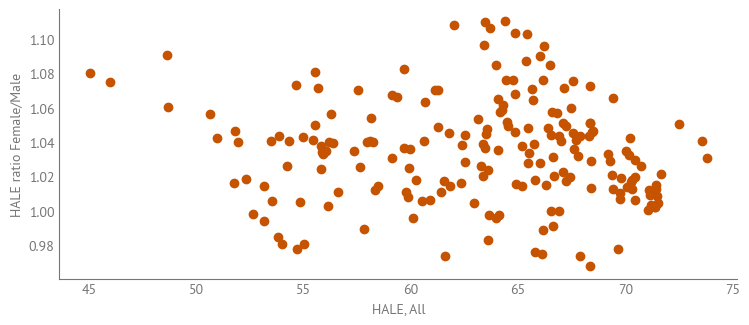

In [20]:
plt.scatter(who['both'], who['ratio'])
plt.xlabel('HALE, All')
plt.ylabel('HALE ratio Female/Male');

In [21]:
from scipy.stats import linregress

linregress(who['both'], who['ratio'])

LinregressResult(slope=-0.0004837180276191493, intercept=1.065432413313727, rvalue=-0.0965338706579513, pvalue=0.17831047993415736, stderr=0.0003580788347397275, intercept_stderr=0.02270347960221574)

## Compute Scores

In [105]:
who['score'] = 1.06 - np.abs(who['ratio'] - 1)

In [106]:
who['score'].describe()

count    196.000000
mean       1.021996
std        0.026198
min        0.949601
25%        1.008824
50%        1.024807
75%        1.043114
max        1.059995
Name: score, dtype: float64

In [109]:
who['score_truncated'] = np.where(who['ratio'] > 1.06, 1.06, who['ratio'])

In [110]:
who['score_truncated'].describe()

count    196.000000
mean       1.030965
std        0.024032
min        0.967509
25%        1.013980
50%        1.035193
75%        1.051176
max        1.060000
Name: score_truncated, dtype: float64

Add the OWID data to WEF

In [111]:
def merge_column(wef, series, col):
    wef[col] = np.nan

    for code, score in series.items():
        if code in wef.index:
            wef.loc[code, col] = score

    missing = wef[col].isna()
    return wef.index[missing]

In [112]:
merge_column(wef, who['male'], 'male')
merge_column(wef, who['female'], 'female')
merge_column(wef, who['ratio'], 'who_ratio')
merge_column(wef, who['score'], 'who_score')
merge_column(wef, who['score_truncated'], 'who_score_truncated')

Index([], dtype='object', name='code')

In [113]:
wef['who_score'].describe()

count    146.000000
mean       1.023400
std        0.027000
min        0.949601
25%        1.010618
50%        1.027172
75%        1.044780
max        1.059995
Name: who_score, dtype: float64

In [114]:
wef['who_score_truncated'].describe()

count    146.000000
mean       1.029310
std        0.024297
min        0.967509
25%        1.012188
50%        1.032827
75%        1.049382
max        1.060000
Name: who_score_truncated, dtype: float64

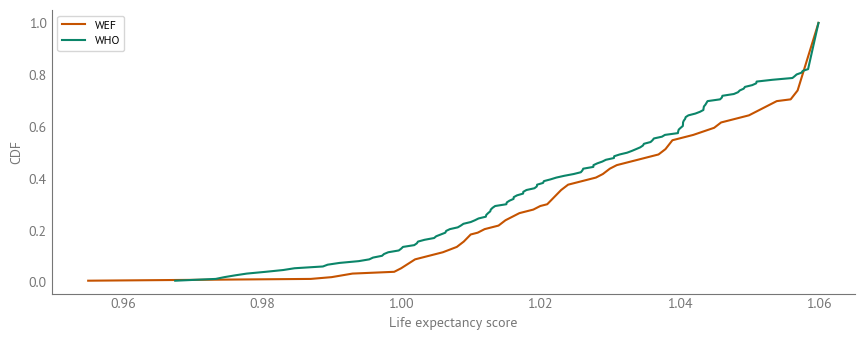

In [115]:
from empiricaldist import Cdf

cdf_wef = Cdf.from_seq(wef['score'])
cdf_owid = Cdf.from_seq(wef['who_score_truncated'])

cdf_wef.plot(label='WEF')
cdf_owid.plot(label='WHO')
decorate(xlabel='Life expectancy score', ylabel='CDF')

In [116]:
wef_truncated = wef['score'] == 1.06
who_truncated = wef['who_score_truncated'] == 1.06
wef_truncated.sum(), who_truncated.sum()

(38, 26)

In [117]:
# Create a crosstab to count cases in each quadrant
truncation_counts = pd.crosstab(wef_truncated, who_truncated, 
                               rownames=['WEF Truncated'], 
                               colnames=['WHO Truncated'])

print(truncation_counts)

WHO Truncated  False  True 
WEF Truncated              
False            107      1
True              13     25


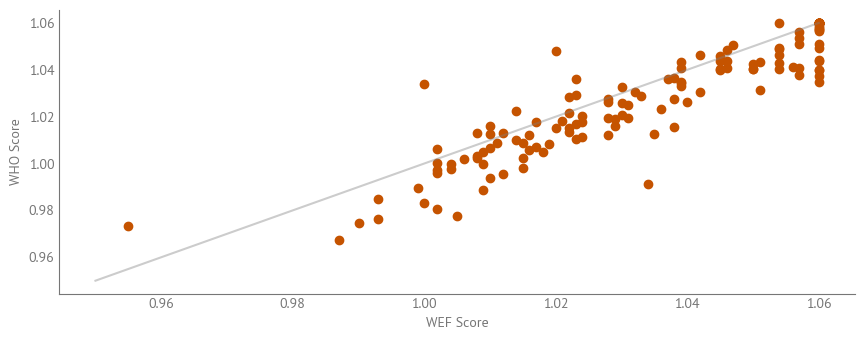

In [118]:
plt.plot([0.95, 1.06], [0.95, 1.06], color='gray', alpha=0.4)
plt.scatter(wef['score'], wef['who_score_truncated'])
decorate(xlabel='WEF Score', ylabel='WHO Score')

## Our World In Data

https://ourworldindata.org/why-do-women-live-longer-than-men

In [119]:
import requests

filename = 'life-expectancy-of-women-vs-life-expectancy-of-men.csv'

In [120]:
owid = pd.read_csv(filename)
owid.columns = ['Entity', 'Code', 'Year',
       'life_expectancy_female',
       'life_expectancy_male',
       'population',
       'region', 'time', 'time.1']
owid.index = owid['Code']

In [121]:
owid.head()

,Entity,Code,Year,life_expectancy_female,life_expectancy_male,population,region,time,time.1
Code,,,,,,,,,
AFG,Afghanistan,AFG,2023,67.536,64.467,41454709,Asia,2023,2023
ALB,Albania,ALB,2023,81.446,77.728,2811615,Europe,2023,2023
DZA,Algeria,DZA,2023,77.696,74.895,46164169,Africa,2023,2023
ASM,American Samoa,ASM,2023,75.838,70.202,47499,Oceania,2023,2023
AND,Andorra,AND,2023,86.107,82.100,80825,Europe,2023,2023


In [122]:
owid['ratio'] = owid['life_expectancy_female'] / owid['life_expectancy_male']

In [123]:
owid.sort_values(by='ratio').head()

,Entity,Code,Year,life_expectancy_female,life_expectancy_male,population,region,time,time.1,ratio
Code,,,,,,,,,,
TGO,Togo,TGO,2023,62.923,62.536,9304289,Africa,2023,2023,1.006188
NGA,Nigeria,NGA,2023,54.743,54.176,227882899,Africa,2023,2023,1.010466
BHR,Bahrain,BHR,2023,81.987,80.672,1569625,Asia,2023,2023,1.016301
QAT,Qatar,QAT,2023,83.368,81.611,2979038,Asia,2023,2023,1.021529
WLF,Wallis and Futuna,WLF,2023,79.616,77.661,11360,Oceania,2023,2023,1.025174


In [124]:
owid.sort_values(by='ratio').tail()

,Entity,Code,Year,life_expectancy_female,life_expectancy_male,population,region,time,time.1,ratio
Code,,,,,,,,,,
GEO,Georgia,GEO,2023,79.107,69.569,3807436,Asia,2023,2023,1.137101
VIR,United States Virgin Islands,VIR,2023,81.352,70.513,85666,North America,2023,2023,1.153716
RUS,Russia,RUS,2023,79.037,67.256,145440454,Europe,2023,2023,1.175167
PSE,Palestine,PSE,2023,71.502,59.691,5409153,Asia,2023,2023,1.197869
UKR,Ukraine,UKR,2023,80.198,66.900,37732781,Europe,2023,2023,1.198774


In [125]:
owid['ratio'].describe()

count    237.000000
mean       1.074146
std        0.028507
min        1.006188
25%        1.055361
50%        1.070374
75%        1.088589
max        1.198774
Name: ratio, dtype: float64

In [126]:
owid['score'] = 1.06 - np.abs(owid['ratio'] - 1.06)

In [127]:
owid['score'].describe()

count    237.000000
mean       1.037337
std        0.022311
min        0.921226
25%        1.030400
50%        1.043895
75%        1.052358
max        1.059994
Name: score, dtype: float64

In [128]:
owid['score_truncated'] = np.where(owid['ratio'] > 1.06, 1.06, owid['score'])

In [129]:
owid['score_truncated'].describe()

count    237.000000
mean       1.055741
std        0.008865
min        1.006188
25%        1.055361
50%        1.060000
75%        1.060000
max        1.060000
Name: score_truncated, dtype: float64

Add the OWID data to WEF

In [130]:
def merge_column(wef, series, col):
    wef[col] = np.nan

    for code, score in series.items():
        if code in wef.index:
            wef.loc[code, col] = score

    missing = wef[col].isna()
    return wef.index[missing]

In [131]:
merge_column(wef, owid['score'], 'owid_score')
merge_column(wef, owid['score_truncated'], 'owid_score_truncated')

Index([], dtype='object', name='code')

In [132]:
wef['owid_score'].describe()

count    146.000000
mean       1.037539
std        0.021267
min        0.921226
25%        1.031114
50%        1.044479
75%        1.051188
max        1.059974
Name: owid_score, dtype: float64

In [133]:
wef['owid_score_truncated'].describe()

count    146.000000
mean       1.054905
std        0.010010
min        1.006188
25%        1.052430
50%        1.060000
75%        1.060000
max        1.060000
Name: owid_score_truncated, dtype: float64

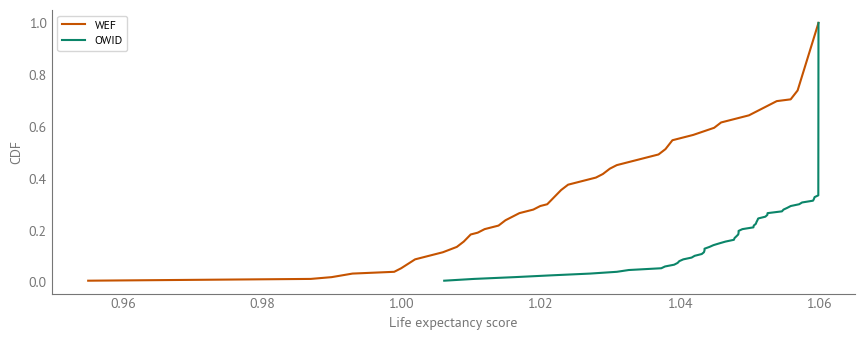

In [134]:
cdf_wef = Cdf.from_seq(wef['score'])
cdf_owid = Cdf.from_seq(wef['owid_score_truncated'])

cdf_wef.plot(label='WEF')
cdf_owid.plot(label='OWID')
decorate(xlabel='Life expectancy score', ylabel='CDF')

In [135]:
wef_truncated = wef['score'] == 1.06 
owid_truncated = wef['owid_score_truncated'] == 1.06  
wef_truncated.sum(), owid_truncated.sum()

(38, 97)

In [136]:
# Create a crosstab to count cases in each quadrant
truncation_counts = pd.crosstab(wef_truncated, owid_truncated, 
                               rownames=['WEF Truncated'], 
                               colnames=['OWID Truncated'])

print(truncation_counts)

OWID Truncated  False  True 
WEF Truncated               
False              49     59
True                0     38


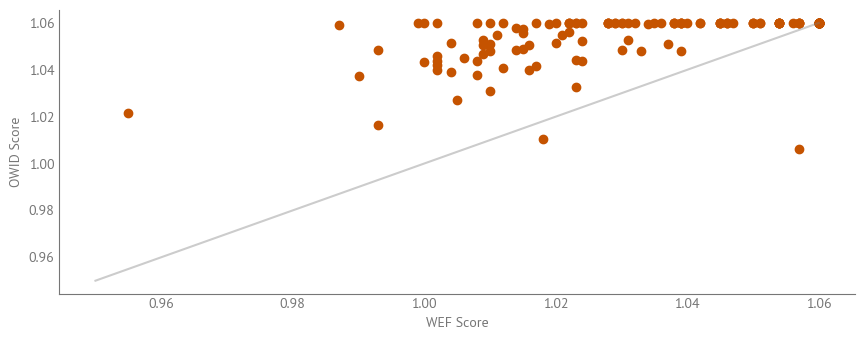

In [137]:
plt.plot([0.95, 1.06], [0.95, 1.06], color='gray', alpha=0.4)
plt.scatter(wef['score'], wef['owid_score_truncated'])
decorate(xlabel='WEF Score', ylabel='OWID Score')

## Revised Scores

Here's the distribution of revised scores.

In [138]:
wef['ratio'] = wef['who_ratio']
wef['revised_score'] = wef['who_score']
wef['revised_score'].describe()

count    146.000000
mean       1.023400
std        0.027000
min        0.949601
25%        1.010618
50%        1.027172
75%        1.044780
max        1.059995
Name: revised_score, dtype: float64

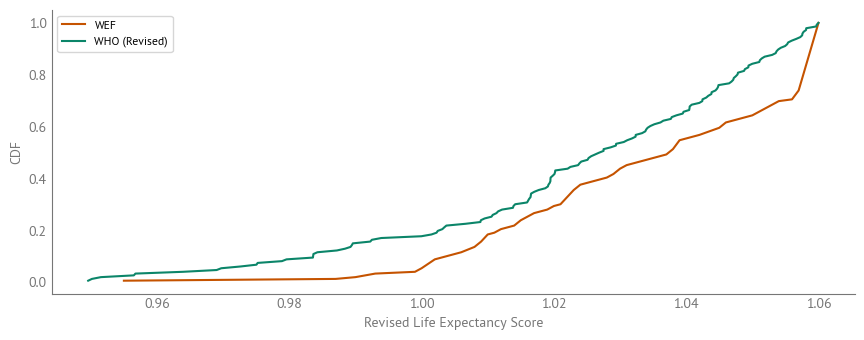

In [139]:
cdf_score = Cdf.from_seq(wef['score'])
cdf_score.plot(label='WEF')
cdf_revised = Cdf.from_seq(wef['revised_score'])
cdf_revised.plot(label='WHO (Revised)')
decorate(xlabel='Revised Life Expectancy Score', ylabel='CDF')

In [140]:
wef_sorted = wef.sort_values(by='score', ascending=False)

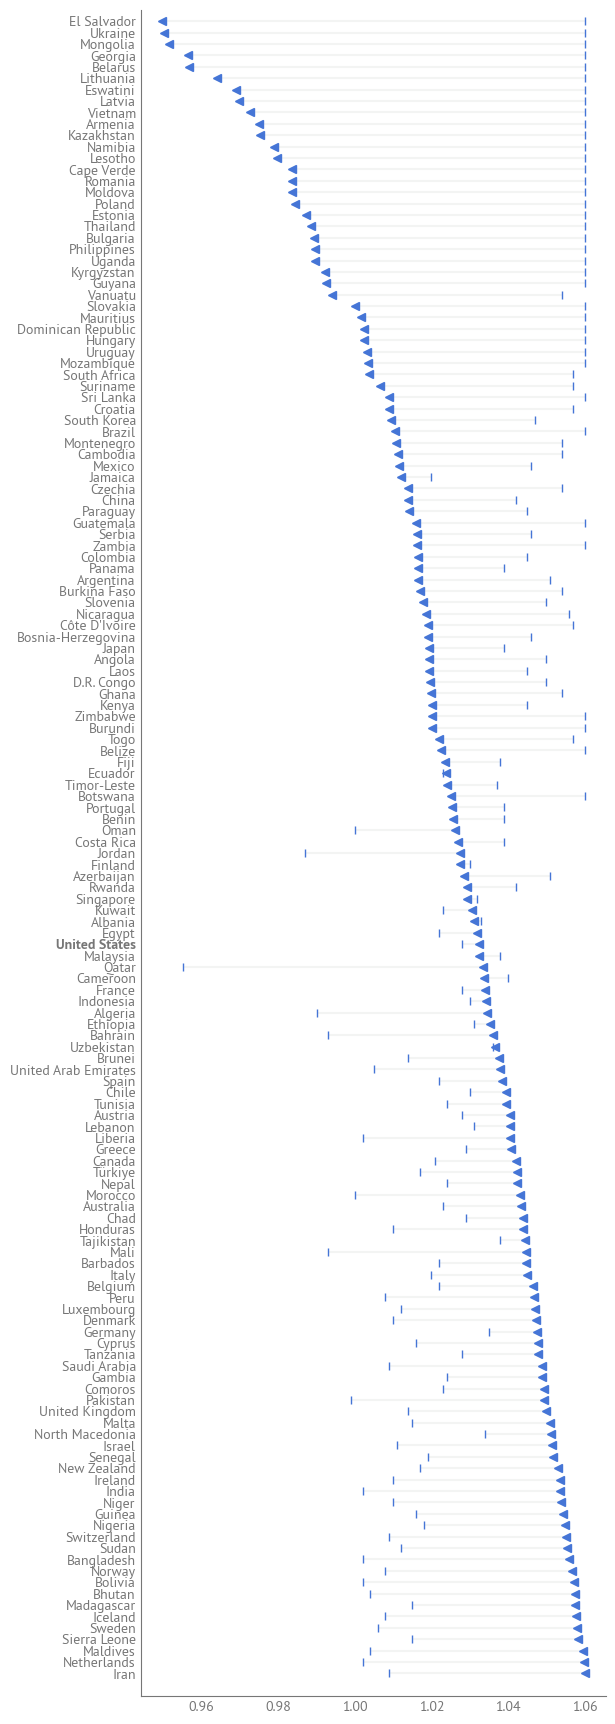

In [141]:
from utils import plot_revised_scores

plot_revised_scores(wef.sort_values('revised_score'))

## Export the results

In [142]:
from utils import make_rank_table

table = make_rank_table(wef)
table.head()

,country,ratio,rank,revised_rank,score,revised_score
code,,,,,,
ALB,Albania,1.028918,79,67.0,1.033,1.031082
DZA,Algeria,0.974586,144,59.0,0.990,1.034586
AGO,Angola,1.040526,55,90.0,1.050,1.019474
ARG,Argentina,1.043446,51,97.0,1.051,1.016554
ARM,Armenia,1.084958,1,137.0,1.060,0.975042


In [143]:
table.to_csv("wef_life_expectancy_table.csv")
table.shape

(146, 6)

In [144]:
from utils import make_weight_table

make_weight_table(table, 'life_expectancy')

original           revised          
                     std   inv std     std   inv std
life_expectancy  0.02247  0.445044   0.027  0.370368

In [145]:
from utils import oecd_codes

df_oecd = wef.loc[oecd_codes].sort_values(by='revised_score')
df_oecd.sort_values(by='ratio').head()

,country,page_number,score,rank,who_ratio,who_score,who_score_truncated,owid_score,owid_score_truncated,ratio,revised_score,revised_rank,male,female
code,,,,,,,,,,,,,,
NLD,Netherlands,273,1.002,135,1.000262,1.059738,1.000262,1.039745,1.039745,1.000262,1.059738,2.0,71.052035,71.070623
SWE,Sweden,335,1.006,130,1.001879,1.058121,1.001879,1.044902,1.044902,1.001879,1.058121,5.0,71.327303,71.461329
ISL,Iceland,203,1.008,129,1.002247,1.057753,1.002247,1.043529,1.043529,1.002247,1.057753,6.0,71.302050,71.462248
NOR,Norway,285,1.008,127,1.003360,1.056640,1.003360,1.037934,1.037934,1.003360,1.056640,10.0,71.042668,71.281402
CHE,Switzerland,337,1.009,125,1.004735,1.055265,1.004735,1.046629,1.046629,1.004735,1.055265,13.0,71.330820,71.668585


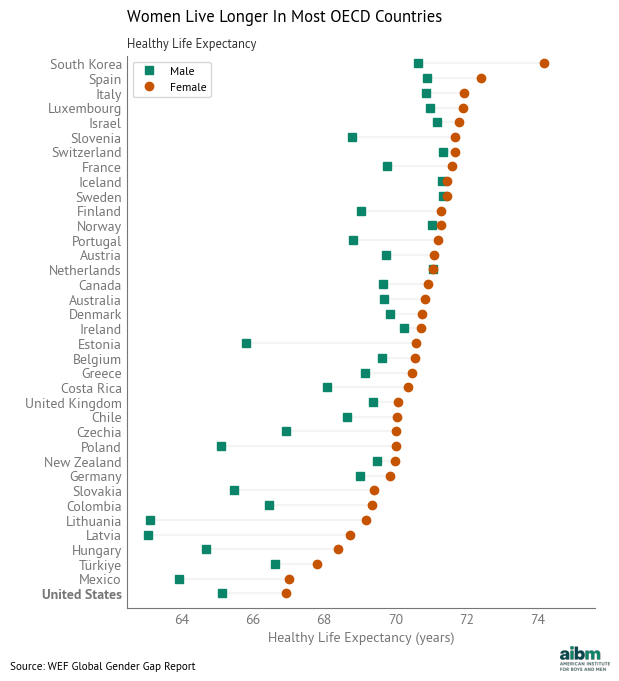

In [146]:
from utils import plot_indicators

plot_indicators(df_oecd)
plt.xlabel('Healthy Life Expectancy (years)')
add_title("Women Live Longer In Most OECD Countries",
          "Healthy Life Expectancy", y=1.01)


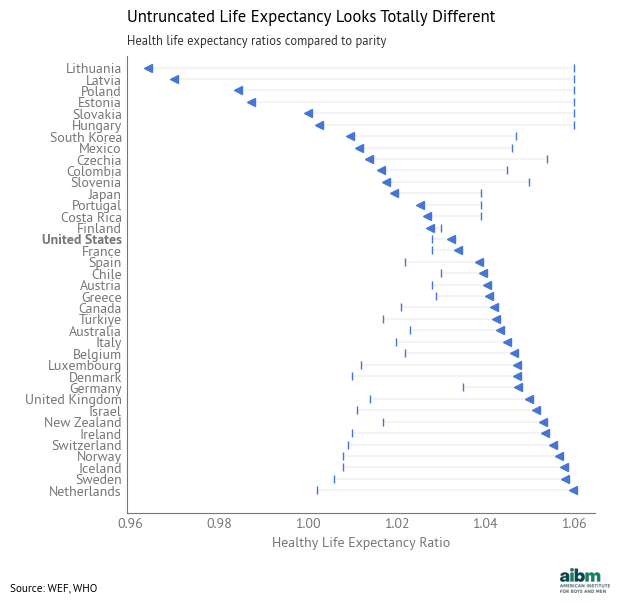

In [147]:
from utils import add_title, add_subtext, add_logo

plot_revised_scores(df_oecd)

add_title("Untruncated Life Expectancy Looks Totally Different",
    "Health life expectancy ratios compared to parity", y=1.02
)
decorate(xlabel='Healthy Life Expectancy Ratio')
add_subtext("Source: WEF, WHO", y=-0.05)
logo = add_logo(location=(1.0, -0.05))

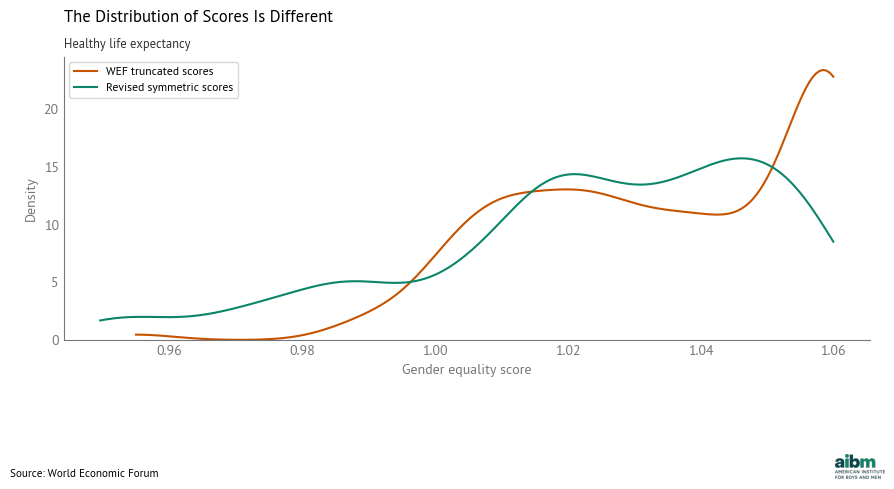

In [148]:
import seaborn as sns

options = dict(cut=0, bw_adjust=0.7)

sns.kdeplot(wef['score'], label='WEF truncated scores', **options)
sns.kdeplot(wef['revised_score'], label='Revised symmetric scores', **options)

decorate(xlabel='Gender equality score')

add_title("The Distribution of Scores Is Different",
          "Healthy life expectancy")
add_subtext("Source: World Economic Forum", y=-0.25)
logo = add_logo(location=(1.0, -0.25))
None